# IMPORTS

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest , GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw , integrated_brier_score
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import category_encoders as ce
import mygene
from sklearn.preprocessing import MultiLabelBinarizer

In [3]:
mol_df = pl.read_csv("../data/processed/X_train/molecular_train_preprocess_v2.csv")
cl_df = pl.read_csv("../data/processed/X_train/clinical_train_preprocess.csv")
y = pl.read_csv("../data/processed/target_preprocess.csv")

In [4]:
mol_df

ID,GENE_count,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,has_inframe_codon_loss,has_ITD,has_initiator_codon_change,has_frameshift_variant,has_non_synonymous_codon,has_stop_gained,has_2KB_upstream_variant,has_inframe_variant,has_3_prime_UTR_variant,has_synonymous_codon,has_splice_site_variant,has_stop_retained_variant,has_inframe_codon_gain,has_complex_change_in_transcript,has_PTD,has_stop_lost,has_is_frameshift,has_is_non_sens_mutation,has_IS_MISSENSE,has_complex_nucleotide_REF,has_complex_nucleotide_ALT,has_is_transition,has_is_transversion,has_is_indel,CHR_mean,CHR_max,CHR_min,mutations_per_gene_mean,mutations_per_gene_max,mutations_per_gene_min,mutations_per_gene_effect_mean,mutations_per_gene_effect_max,mutations_per_gene_effect_min,mutations_per_region_mean,mutations_per_region_max,mutations_per_region_min
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""P106095""",2,0.2135,0.391,0.036,1049.0,1332.0,766.0,1.1278e8,1.19388864e8,1.06164013e8,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,13.5,23.0,4.0,0.513237,1.0,0.026474,0.285622,0.53886,0.032383,0.002066,0.004132,0.0
"""P110889""",4,0.2605,0.465,0.024,491.5,671.0,179.0,1.0661e8,1.98266834e8,1.5836766e7,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,8.25,23.0,2.0,0.645758,1.0,0.117329,0.543394,1.0,0.054404,0.231921,0.880165,0.0
"""P117196""",4,0.308475,0.4655,0.0355,351.0,612.0,198.0,1.0553e8,1.48507475e8,3.1022441e7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,1,0,1,18.25,23.0,7.0,0.243682,0.5716,0.026474,0.317358,0.926166,0.016839,0.191116,0.764463,0.0
"""P105510""",2,0.1985,0.287,0.11,1934.0,2185.0,1683.0,1.22276268e8,1.98266834e8,4.6285702e7,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,7.0,12.0,2.0,0.243682,0.465704,0.021661,0.504534,1.0,0.009067,0.440083,0.880165,0.0
"""P116706""",3,0.475333,0.483,0.468,743.666667,967.0,619.0,9.5694e7,1.06193778e8,7.4732959e7,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,8.333333,17.0,4.0,0.78219,1.0,0.34657,0.603195,0.648964,0.580311,0.349862,1.0,0.008264
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P118199""",4,0.21315,0.286,0.1376,838.75,1552.0,482.0,5.9666348e7,1.23197044e8,3.1022441e7,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,1,0,1,21.75,23.0,20.0,0.274368,0.5716,0.127557,0.391516,0.926166,0.073834,0.253099,0.764463,0.0
"""P121022""",7,0.192271,0.413,0.028,890.142857,1369.0,510.0,6.1713e7,1.28200691e8,3.78124e6,0,0,0,1,1,1,0,0,0,0,1,0,0,0,0,0,1,1,1,0,1,1,1,1,16.857143,23.0,3.0,0.162197,0.5716,0.018051,0.23057,0.926166,0.020725,0.172078,0.764463,0.0
"""P116674""",2,0.4896,0.5379,0.4413,648.5,901.0,396.0,3.7414269e7,4.3806136e7,3.1022402e7,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,1,0,0,1,10.5,20.0,1.0,0.306859,0.5716,0.042118,0.463083,0.926166,0.0,0.115702,0.231405,0.0


In [7]:
full_df = cl_df.join(mol_df , on="ID" , how="left").join(y,on="ID",how="left")

In [10]:
full_df.null_count()

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo,GENE_count,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,has_inframe_codon_loss,has_ITD,has_initiator_codon_change,has_frameshift_variant,has_non_synonymous_codon,has_stop_gained,has_2KB_upstream_variant,has_inframe_variant,has_3_prime_UTR_variant,has_synonymous_codon,has_splice_site_variant,has_stop_retained_variant,has_inframe_codon_gain,has_complex_change_in_transcript,has_PTD,has_stop_lost,has_is_frameshift,has_is_non_sens_mutation,has_IS_MISSENSE,has_complex_nucleotide_REF,has_complex_nucleotide_ALT,has_is_transition,has_is_transversion,has_is_indel,CHR_mean,CHR_max,CHR_min,mutations_per_gene_mean,mutations_per_gene_max,mutations_per_gene_min,mutations_per_gene_effect_mean,mutations_per_gene_effect_max,mutations_per_gene_effect_min,mutations_per_region_mean,mutations_per_region_max,mutations_per_region_min,time,event
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,298,300,300,300,300,300,300,300,300,300,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,0,0


In [11]:
import polars as pl

cols_to_fill = [
    "has_inframe_codon_loss", "has_ITD", "has_initiator_codon_change", "has_frameshift_variant",
    "has_non_synonymous_codon", "has_stop_gained", "has_2KB_upstream_variant", "has_inframe_variant",
    "has_3_prime_UTR_variant", "has_synonymous_codon", "has_splice_site_variant",
    "has_stop_retained_variant", "has_inframe_codon_gain", "has_complex_change_in_transcript",
    "has_PTD", "has_stop_lost", "has_is_frameshift", "has_is_non_sens_mutation",
    "has_IS_MISSENSE", "has_complex_nucleotide_REF", "has_complex_nucleotide_ALT",
    "has_is_transition", "has_is_transversion", "has_is_indel"
]


full_df = full_df.with_columns([
    pl.col(col).fill_null(strategy="forward") for col in cols_to_fill
])


In [14]:
cols_to_impute = [
    "GENE_count", "VAF_mean", "VAF_max", "VAF_min",
    "DEPTH_mean", "DEPTH_max", "DEPTH_min",
    "START_mean", "START_max", "START_min",
    "CHR_mean", "CHR_max", "CHR_min",
    "mutations_per_gene_mean", "mutations_per_gene_max", "mutations_per_gene_min",
    "mutations_per_gene_effect_mean", "mutations_per_gene_effect_max", "mutations_per_gene_effect_min",
    "mutations_per_region_mean", "mutations_per_region_max", "mutations_per_region_min"
]


full_df = full_df.with_columns([
    pl.col(col).fill_null(pl.col(col).mean()).alias(col) for col in cols_to_impute
])

In [ ]:
mol_df_t = mol_df.group_by("ID").mean()


def pl_when(df, cols):
    return df.with_columns([
        pl.when(pl.col(col) >= 0.5).then(1).otherwise(0).alias(col)
        for col in cols
    ])

# Liste des colonnes à binariser
cols = [
    "EFFECT_0", "EFFECT_1", "EFFECT_2", "EFFECT_3",
    "AA_TYPE_0", "AA_TYPE_1", "AA_TYPE_2", "AA_TYPE_3", "AA_TYPE_4",
    "IS_PT_UKNOWN", "is_frameshift", "is_non_sens_mutation", "IS_MISSENSE",
    "REF_is_SNV_A", "REF_is_SNV_C", "REF_is_SNV_G", "REF_is_SNV_T",
    "ALT_is_SNV_A", "ALT_is_SNV_C", "ALT_is_SNV_G", "ALT_is_SNV_T",
    "complex_nucleotide_REF", "complex_nucleotide_ALT",
    "is_transition", "is_transversion", "is_indel"
]

# Application
mol_df_t = pl_when(mol_df_t, cols)


mol_df_t

ID,CHR,START,END,EFFECT_0,EFFECT_1,EFFECT_2,EFFECT_3,VAF,DEPTH,mutations_per_gene,mutations_per_gene_effect,mutations_per_region,AA_TYPE_0,AA_TYPE_1,AA_TYPE_2,AA_TYPE_3,AA_TYPE_4,IS_PT_UKNOWN,is_frameshift,is_non_sens_mutation,IS_MISSENSE,REF_is_SNV_A,REF_is_SNV_C,REF_is_SNV_G,REF_is_SNV_T,ALT_is_SNV_A,ALT_is_SNV_C,ALT_is_SNV_G,ALT_is_SNV_T,complex_nucleotide_REF,complex_nucleotide_ALT,is_transition,is_transversion,is_indel
str,f64,f64,f64,i32,i32,i32,i32,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
"""P102847""",15.333333,0.093553,0.093553,0,0,0,1,0.2874,0.863385,0.201163,0.177461,0.003444,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0
"""P121054""",12.0,0.143163,0.143163,0,0,0,1,0.13835,0.455081,0.124097,0.079016,0.067665,1,0,0,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0
"""P121084""",4.0,0.468329,0.468329,0,0,1,0,0.283,0.450522,1.0,0.580311,0.014463,0,0,1,1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0
"""P131522""",10.333333,0.370614,0.370614,0,0,1,0,0.248,0.436216,0.709186,0.411485,0.002066,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0
"""P120371""",10.5,0.250038,0.250038,0,1,0,1,0.67305,0.479697,0.646209,0.674223,0.0,1,1,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,0,1,0,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P105740""",12.4,0.356755,0.356755,0,1,0,0,0.57702,0.525142,0.207942,0.339637,0.042562,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
"""P100157""",13.0,0.282881,0.282881,0,0,0,1,0.268,0.399677,0.154332,0.267055,0.221074,1,0,1,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0
"""P105742""",10.5,0.398706,0.398706,0,1,0,1,0.5381,0.275615,0.673285,0.767487,0.5,1,0,0,1,1,0,1,1,1,0,0,1,1,0,1,0,0,0,1,0,1,1


In [34]:
mol_df_t = mol_df.groupby('ID').size().reset_index(name='Nmut')

mol_df_t = pl.from_pandas(mol_df_t)

mol_df_t

ID,Nmut
str,i64
"""P100000""",6
"""P100001""",2
"""P100002""",2
"""P100004""",1
"""P100006""",5
…,…
"""P132725""",5
"""P132726""",1
"""P132727""",2


In [91]:
merge_cl_y = cl_df.join(other=mol_df_t , on="ID" , how="left")

final_df = merge_cl_y.join(other=y , on="ID" , how="left")

In [92]:
final_df

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo,CHR,START,END,EFFECT_0,EFFECT_1,EFFECT_2,EFFECT_3,VAF,DEPTH,mutations_per_gene,mutations_per_gene_effect,mutations_per_region,AA_TYPE_0,AA_TYPE_1,AA_TYPE_2,AA_TYPE_3,AA_TYPE_4,IS_PT_UKNOWN,is_frameshift,is_non_sens_mutation,IS_MISSENSE,REF_is_SNV_A,REF_is_SNV_C,REF_is_SNV_G,REF_is_SNV_T,ALT_is_SNV_A,ALT_is_SNV_C,ALT_is_SNV_G,ALT_is_SNV_T,complex_nucleotide_REF,complex_nucleotide_ALT,is_transition,is_transversion,is_indel,time,event
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i32,i32,i32,i32,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,bool
"""P132697""",0.756757,0.209677,0.02589,0.7,0.291667,0.246835,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12.333333,0.179409,0.179409,0,0,0,1,0.251578,0.683732,0.282123,0.30095,0.106749,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1.115068,true
"""P132698""",0.054054,0.580645,0.31068,0.1,0.662037,0.084388,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19.0,0.103001,0.103001,0,1,0,0,0.272867,0.58293,0.312274,0.417962,0.25551,0,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,4.928767,false
"""P116889""",0.810811,0.282258,0.271845,0.1,0.902778,0.166667,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,6.666667,0.557879,0.557879,0,0,1,0,0.039333,0.73792,0.218211,0.356218,0.028926,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,2.043836,false
"""P132699""",0.054054,0.298387,0.245955,0.1,0.412037,0.158228,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15.181818,0.298245,0.298245,0,0,0,1,0.209227,0.475451,0.14517,0.156382,0.034936,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,2.476712,true
"""P132700""",0.324324,1.0,1.0,0.9,0.615741,0.407173,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,20.0,0.135606,0.135606,0,1,0,0,0.4721,0.293288,0.5716,0.926166,0.764463,0,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,3.145205,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""",0.054054,0.282258,0.327508,0.53,0.412037,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19.0,0.161085,0.161085,0,1,0,1,0.397,0.286766,0.324007,0.545337,0.408058,0,1,1,0,1,0,1,1,1,1,0,1,0,0,0,0,1,0,1,0,1,1,2.351739,false
"""P121829""",0.0,0.322581,0.31068,0.22,0.569444,0.099156,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,23.0,0.234826,0.234826,0,0,0,1,0.042,0.305912,0.016847,0.033679,0.010331,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,2.351739,false
"""P121830""",0.0,0.129032,0.071197,0.29,0.458333,0.177215,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,13.5,0.357952,0.357952,0,0,0,1,0.24465,0.316782,0.232952,0.18329,0.07197,0,1,1,1,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1.99726,false


In [93]:
final_df.null_count()

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo,CHR,START,END,EFFECT_0,EFFECT_1,EFFECT_2,EFFECT_3,VAF,DEPTH,mutations_per_gene,mutations_per_gene_effect,mutations_per_region,AA_TYPE_0,AA_TYPE_1,AA_TYPE_2,AA_TYPE_3,AA_TYPE_4,IS_PT_UKNOWN,is_frameshift,is_non_sens_mutation,IS_MISSENSE,REF_is_SNV_A,REF_is_SNV_C,REF_is_SNV_G,REF_is_SNV_T,ALT_is_SNV_A,ALT_is_SNV_C,ALT_is_SNV_G,ALT_is_SNV_T,complex_nucleotide_REF,complex_nucleotide_ALT,is_transition,is_transversion,is_indel,time,event
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,0,0


In [38]:
final_df = final_df.with_columns(
    pl.col("Nmut").fill_null(pl.col("Nmut").mean())
)

In [95]:
col_median = ["START" , "END" , "mutations_per_gene" , "mutations_per_gene_effect" , "mutations_per_region" , "VAF" , "DEPTH"]

final_df = final_df.with_columns([
    pl.col(c).fill_null(pl.col(c).mean()) for c in col_median if c in final_df.columns
])

In [96]:
col_common = [
    "CHR", "EFFECT_0", "EFFECT_1", "EFFECT_2", "EFFECT_3",
    "AA_TYPE_0", "AA_TYPE_1", "AA_TYPE_2", "AA_TYPE_3", "AA_TYPE_4",
    "IS_PT_UKNOWN", "is_frameshift", "is_non_sens_mutation", "IS_MISSENSE",
    "REF_is_SNV_A", "REF_is_SNV_C", "REF_is_SNV_G", "REF_is_SNV_T",
    "ALT_is_SNV_A", "ALT_is_SNV_C", "ALT_is_SNV_G", "ALT_is_SNV_T",
    "complex_nucleotide_REF", "complex_nucleotide_ALT",
    "is_transition", "is_transversion", "is_indel"
]

new_cols = [
    "is_a_Man", "is_a_Female", "is_deletion_anomaly", "is_inversion_anomaly", "is_added_anomaly",
    "is_down_syndrome", "is_monosomy", "is_7_deleted", "is_trisomy_8", "iso_chromosome",
    "is_derived_chromosome", "is_lost_sex_chromosome", "is_added_chromsome", "is_deleted_chromsome",
    "is_inserted_chromsome", "is_translocated_anomaly", "is_complex_karyo"
]

col_common +=new_cols

# Exemple sur un DataFrame `df`
# Appliquer fill_null (strategy = "backward") uniquement sur les colonnes de col_common
final_df = final_df.with_columns([
    pl.col(c).fill_null(strategy="forward") for c in col_common if c in final_df.columns
])

In [97]:
df = final_df.drop("ID")

In [18]:
full_df_noID = full_df.drop("ID")

# BEFORE FEATURE SELECTION

In [19]:
X = full_df_noID.drop(["time"  , "event"])

y = Surv.from_dataframe(event="event"  , time="time" , data=full_df_noID.to_pandas())


In [20]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 ,random_state=42)

models = {"CoxPH": CoxPHSurvivalAnalysis(alpha=1e-4, n_iter=1000),
        "Random Survival Forest": RandomSurvivalForest(n_estimators=100, min_samples_split=10, min_samples_leaf=15, random_state=42),
        "GradientBoosting" : GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0)
    }

In [21]:
# Appliquer les modèles et afficher le C-index
for name, model in models.items():
    model.fit(X_train, y_train)
    
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_ci_ipcw = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
    test_ci_ipcw = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
    
    
    
    print("----------")
    
    
    print(f"{name} Survival Model Concordance Index IPCW on train: {train_ci_ipcw:.2f}")
    print(f"{name} Survival Model Concordance Index IPCW on test: {test_ci_ipcw:.2f}")
    
    
    

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.19713e-23): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.21964e-23): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.31221e-23): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.34084e-23): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.34

----------
CoxPH Survival Model Concordance Index IPCW on train: 0.71
CoxPH Survival Model Concordance Index IPCW on test: 0.68
----------
Random Survival Forest Survival Model Concordance Index IPCW on train: 0.78
Random Survival Forest Survival Model Concordance Index IPCW on test: 0.69
----------
GradientBoosting Survival Model Concordance Index IPCW on train: 0.73
GradientBoosting Survival Model Concordance Index IPCW on test: 0.68


In [13]:
# from sklearn.feature_selection import VarianceThreshold

# threshold = 0.01
# selected_cols = []
# cpt = 0

# for col in df.columns:
#     var = df[col].var()
#     if var > threshold:
#         print(f"Variance de {col} : {var}")
#         selected_cols.append(col)
#         cpt += 1
#     else:
#         print(f"Variable supprimée : {col} , Variance : {var}")

# print(f"Nombre de variables conservées : {cpt} / {df.shape[1]}")

# df_filtered = df[selected_cols]


In [101]:
df_filtered = df

In [75]:
from scipy.stats import pearsonr


col_to_drop = set()

for col in df.columns:
    for col1 in df.columns:
        if col == col1 or (col1, col) in col_to_drop:
            continue

        corr, _ = pearsonr(df[col], df[col1])

        if abs(corr) >= 0.88:
            print(f"Corrélation entre {col} et {col1} : {corr:.2f}")
            col_to_drop.add(col)

Corrélation entre WBC et ANC : 0.91
Corrélation entre ANC et WBC : 0.91
Corrélation entre is_inversion_anomaly et is_down_syndrome : 0.89
Corrélation entre is_inversion_anomaly et is_7_deleted : 0.89
Corrélation entre is_inversion_anomaly et iso_chromosome : 0.91
Corrélation entre is_inversion_anomaly et is_inserted_chromsome : 0.92
Corrélation entre is_down_syndrome et is_inversion_anomaly : 0.89
Corrélation entre is_down_syndrome et is_7_deleted : 0.88
Corrélation entre is_down_syndrome et iso_chromosome : 0.92
Corrélation entre is_down_syndrome et is_inserted_chromsome : 0.92
Corrélation entre is_monosomy et is_deleted_chromsome : 0.90
Corrélation entre is_7_deleted et is_inversion_anomaly : 0.89
Corrélation entre is_7_deleted et is_down_syndrome : 0.88
Corrélation entre is_7_deleted et iso_chromosome : 0.91
Corrélation entre is_7_deleted et is_inserted_chromsome : 0.92
Corrélation entre is_trisomy_8 et is_added_chromsome : 0.91
Corrélation entre iso_chromosome et is_inversion_anoma

In [102]:
df_filtered

BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo,CHR,START,END,EFFECT_0,EFFECT_1,EFFECT_2,EFFECT_3,VAF,DEPTH,mutations_per_gene,mutations_per_gene_effect,mutations_per_region,AA_TYPE_0,AA_TYPE_1,AA_TYPE_2,AA_TYPE_3,AA_TYPE_4,IS_PT_UKNOWN,is_frameshift,is_non_sens_mutation,IS_MISSENSE,REF_is_SNV_A,REF_is_SNV_C,REF_is_SNV_G,REF_is_SNV_T,ALT_is_SNV_A,ALT_is_SNV_C,ALT_is_SNV_G,ALT_is_SNV_T,complex_nucleotide_REF,complex_nucleotide_ALT,is_transition,is_transversion,is_indel,time,event
f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i32,i32,i32,i32,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,bool
0.756757,0.209677,0.02589,0.7,0.291667,0.246835,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12.333333,0.179409,0.179409,0,0,0,1,0.251578,0.683732,0.282123,0.30095,0.106749,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1.115068,true
0.054054,0.580645,0.31068,0.1,0.662037,0.084388,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19.0,0.103001,0.103001,0,1,0,0,0.272867,0.58293,0.312274,0.417962,0.25551,0,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,4.928767,false
0.810811,0.282258,0.271845,0.1,0.902778,0.166667,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,6.666667,0.557879,0.557879,0,0,1,0,0.039333,0.73792,0.218211,0.356218,0.028926,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,2.043836,false
0.054054,0.298387,0.245955,0.1,0.412037,0.158228,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15.181818,0.298245,0.298245,0,0,0,1,0.209227,0.475451,0.14517,0.156382,0.034936,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,2.476712,true
0.324324,1.0,1.0,0.9,0.615741,0.407173,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,20.0,0.135606,0.135606,0,1,0,0,0.4721,0.293288,0.5716,0.926166,0.764463,0,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,3.145205,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.054054,0.282258,0.327508,0.53,0.412037,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19.0,0.161085,0.161085,0,1,0,1,0.397,0.286766,0.324007,0.545337,0.408058,0,1,1,0,1,0,1,1,1,1,0,1,0,0,0,0,1,0,1,0,1,1,2.351739,false
0.0,0.322581,0.31068,0.22,0.569444,0.099156,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,23.0,0.234826,0.234826,0,0,0,1,0.042,0.305912,0.016847,0.033679,0.010331,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,2.351739,false
0.0,0.129032,0.071197,0.29,0.458333,0.177215,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,13.5,0.357952,0.357952,0,0,0,1,0.24465,0.316782,0.232952,0.18329,0.07197,0,1,1,1,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1.99726,false


In [103]:
from lifelines import CoxPHFitter

df_filtered_pd = df_filtered.to_pandas()

cph = CoxPHFitter(penalizer=0.01)
cph.fit(df_filtered_pd , duration_col='time', event_col='event')

# Summary
cph.print_summary()

summary_df = cph.summary

<lifelines.CoxPHFitter: fitted with 3323 total observations, 1651 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 3323
number of events observed = 1672
   partial log-likelihood = -11780.38
         time fit was run = 2025-06-17 21:24:49 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
BM_BLAST                   0.82      2.27      0.09            0.65            0.99                1.91                2.70
WBC                        0.22      1.25      0.24           -0.24            0.68                0.79                1.98
ANC                        0.18      1.20      0.20           -0.20            0.57                0.82                1.77
MONOCYTES                  0.01      1.01      0.07           -0.12            0.14                0.89                1.15
HB                        -1.56      0.21      0.14           -1.83           -1.29                0.16                0.28
PLT                       -0.79      0.45      0.11           -1.01           -0.57                0.36                0.57
is_a_Man                  -0.18      0.84      0.08           -0.33           -0.03                0.72                0.97
is_a_Female               -0.41      0.66      0.08           -0.57           -0.25                0.57                0.78
is_deletion_anomaly        0.11      1.12      0.07           -0.03            0.25                0.97                1.29
is_inversion_anomaly       0.04      1.04      0.18           -0.32            0.39                0.72                1.48
is_added_anomaly           0.00      1.00      0.12           -0.24            0.24                0.79                1.28
is_down_syndrome          -0.69      0.50      0.19           -1.07           -0.31                0.34                0.73
is_monosomy                0.10      1.11      0.13           -0.16            0.36                0.85                1.43
is_7_deleted               0.24      1.28      0.17           -0.08            0.57                0.92                1.77
is_trisomy_8              -0.27      0.76      0.13           -0.52           -0.02                0.59                0.98
iso_chromosome            -0.06      0.94      0.25           -0.55            0.42                0.58                1.52
is_derived_chromosome      0.35      1.42      0.14            0.07            0.63                1.07                1.89
is_lost_sex_chromosome    -0.22      0.80      0.12           -0.46            0.02                0.63                1.02
is_added_chromsome         0.52      1.67      0.12            0.29            0.74                1.33                2.10
is_deleted_chromsome       0.23      1.25      0.13           -0.03            0.48                0.97                1.62
is_inserted_chromsome     -0.03      0.97      0.27           -0.57            0.51                0.57                1.66
is_translocated_anomaly   -0.07      0.93      0.12           -0.30            0.16                0.74                1.17
is_complex_karyo           0.34      1.41      0.12            0.11            0.57                1.12                1.77
CHR                        0.01      1.01      0.01           -0.00            0.02                1.00                1.02
START                     -0.43      0.65      0.67           -1.74            0.88                0.18                2.40
END                       -0.43      0.65      0.67           -1.74            0.88                0.18                2.40
EFFECT_0                   0.35      1.42      0.26           -0.16            0.86                0

In [116]:
# Filtrer les variables avec p-value > 0.01
insignificant_vars = summary_df[summary_df['p'] > 0.01].index.tolist()

print("Variables non significatives (p > 0.01) :", insignificant_vars)

print(f"Taille {len(insignificant_vars)}")

Variables non significatives (p > 0.01) : ['WBC', 'ANC', 'MONOCYTES', 'is_a_Man', 'is_deletion_anomaly', 'is_inversion_anomaly', 'is_added_anomaly', 'is_monosomy', 'is_7_deleted', 'is_trisomy_8', 'iso_chromosome', 'is_derived_chromosome', 'is_lost_sex_chromosome', 'is_deleted_chromsome', 'is_inserted_chromsome', 'is_translocated_anomaly', 'CHR', 'START', 'END', 'EFFECT_0', 'EFFECT_1', 'EFFECT_2', 'EFFECT_3', 'mutations_per_gene', 'mutations_per_gene_effect', 'mutations_per_region', 'AA_TYPE_0', 'AA_TYPE_1', 'AA_TYPE_2', 'AA_TYPE_3', 'AA_TYPE_4', 'IS_PT_UKNOWN', 'is_frameshift', 'is_non_sens_mutation', 'IS_MISSENSE', 'REF_is_SNV_A', 'REF_is_SNV_T', 'ALT_is_SNV_A', 'ALT_is_SNV_C', 'ALT_is_SNV_G', 'ALT_is_SNV_T', 'complex_nucleotide_ALT', 'is_transition', 'is_transversion', 'is_indel']
Taille 45


In [117]:
df_significant = df_filtered_pd.drop(columns=insignificant_vars)


In [118]:
df_significant = df_filtered.to_pandas()

In [119]:
X = df_significant.drop(["time" , "event"] , axis=1)

y = Surv.from_dataframe(event = 'event' , time='time' , data=df_significant)


In [123]:
df_filtered

BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo,CHR,START,END,EFFECT_0,EFFECT_1,EFFECT_2,EFFECT_3,VAF,DEPTH,mutations_per_gene,mutations_per_gene_effect,mutations_per_region,AA_TYPE_0,AA_TYPE_1,AA_TYPE_2,AA_TYPE_3,AA_TYPE_4,IS_PT_UKNOWN,is_frameshift,is_non_sens_mutation,IS_MISSENSE,REF_is_SNV_A,REF_is_SNV_C,REF_is_SNV_G,REF_is_SNV_T,ALT_is_SNV_A,ALT_is_SNV_C,ALT_is_SNV_G,ALT_is_SNV_T,complex_nucleotide_REF,complex_nucleotide_ALT,is_transition,is_transversion,is_indel,time,event
f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i32,i32,i32,i32,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,bool
0.756757,0.209677,0.02589,0.7,0.291667,0.246835,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12.333333,0.179409,0.179409,0,0,0,1,0.251578,0.683732,0.282123,0.30095,0.106749,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1.115068,true
0.054054,0.580645,0.31068,0.1,0.662037,0.084388,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19.0,0.103001,0.103001,0,1,0,0,0.272867,0.58293,0.312274,0.417962,0.25551,0,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,4.928767,false
0.810811,0.282258,0.271845,0.1,0.902778,0.166667,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,6.666667,0.557879,0.557879,0,0,1,0,0.039333,0.73792,0.218211,0.356218,0.028926,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,2.043836,false
0.054054,0.298387,0.245955,0.1,0.412037,0.158228,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15.181818,0.298245,0.298245,0,0,0,1,0.209227,0.475451,0.14517,0.156382,0.034936,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,2.476712,true
0.324324,1.0,1.0,0.9,0.615741,0.407173,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,20.0,0.135606,0.135606,0,1,0,0,0.4721,0.293288,0.5716,0.926166,0.764463,0,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,3.145205,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.054054,0.282258,0.327508,0.53,0.412037,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19.0,0.161085,0.161085,0,1,0,1,0.397,0.286766,0.324007,0.545337,0.408058,0,1,1,0,1,0,1,1,1,1,0,1,0,0,0,0,1,0,1,0,1,1,2.351739,false
0.0,0.322581,0.31068,0.22,0.569444,0.099156,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,23.0,0.234826,0.234826,0,0,0,1,0.042,0.305912,0.016847,0.033679,0.010331,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,2.351739,false
0.0,0.129032,0.071197,0.29,0.458333,0.177215,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,13.5,0.357952,0.357952,0,0,0,1,0.24465,0.316782,0.232952,0.18329,0.07197,0,1,1,1,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1.99726,false


In [124]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

models = {"CoxPH": CoxPHSurvivalAnalysis(),
        "Random Survival Forest": RandomSurvivalForest(random_state=42),
        "GradientBoostingSurvivalAnalysis" : GradientBoostingSurvivalAnalysis()
    }


In [126]:
# Appliquer les modèles et afficher le C-index
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # times = np.linspace(df_significant["time"].min(), df_significant["time"].max(), 100)
    
    
    
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    # score_train = integrated_brier_score(y_train , y_train , pred_train , times)
    # score_test = integrated_brier_score(y_train,y_test,pred_test , times)




    train_ci_ipcw = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
    test_ci_ipcw = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
    
    
    
    print("----------")
    
    
    print(f"{name} Survival Model Concordance Index IPCW on train: {train_ci_ipcw:.2f}")
    print(f"{name} Survival Model Concordance Index IPCW on test: {test_ci_ipcw:.2f}")
    
    # print(f"{name} Survival Model Integrated Brier Score on train : {score_train:.2f}")
    # print(f"{name} Survival Model Integrated Brier Score on test : {score_test:.2f}")
    
    
    
    

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=6.86022e-19): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.88213e-18): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.57027e-17): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=8.71999e-18): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=5.80

----------
CoxPH Survival Model Concordance Index IPCW on train: 0.70
CoxPH Survival Model Concordance Index IPCW on test: 0.68
----------
Random Survival Forest Survival Model Concordance Index IPCW on train: 0.89
Random Survival Forest Survival Model Concordance Index IPCW on test: 0.69
----------
GradientBoostingSurvivalAnalysis Survival Model Concordance Index IPCW on train: 0.75
GradientBoostingSurvivalAnalysis Survival Model Concordance Index IPCW on test: 0.68


In [132]:
from sklearn.model_selection import KFold, GridSearchCV
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import as_concordance_index_ipcw_scorer

model_params = [
    {
        "name": "CoxPH",
        "estimator": CoxPHSurvivalAnalysis(),
        "params": {
            "alpha": [0.001, 0.005, 0.01, 0.05],         # régularisation L2
            "ties": ["breslow", "efron"],
            "n_iter": [100, 200, 300]                    # suffisant dans la plupart des cas
        }
    },
    {
        "name": "RSF",
        "estimator": RandomSurvivalForest(n_jobs=-1, random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],            # éviter trop petit
            "min_samples_split": [5, 10, 15],           # éviter trop faible (overfit)
            "min_samples_leaf": [5, 10, 15],            # feuilles pas trop petites
            "max_features": [0.3, 0.5, "sqrt"]          # contrôle la diversité des arbres
        }
    }
]

kf = KFold(n_splits=10, shuffle=True, random_state=42)

def ipcw_score(estimator, X, y):
    prediction = estimator.predict(X)
    result = concordance_index_ipcw(y, y, prediction, tau=7)
    return result[0]

for model in model_params:
    name = model["name"]
    estimator = model["estimator"]
    params = model["params"]



    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=params,
        cv=kf,
        scoring=ipcw_score,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    print("Modèle :", name)
    print("Meilleurs paramètres trouvés :", grid_search.best_params_)
    print("Score de validation croisée :", grid_search.best_score_)
    print("-" * 50)

Modèle : CoxPH
Meilleurs paramètres trouvés : {'alpha': 0.05, 'n_iter': 100, 'ties': 'breslow'}
Score de validation croisée : 0.6818243068696146
--------------------------------------------------


KeyboardInterrupt: 

In [131]:
from sksurv.ensemble import ComponentwiseGradientBoostingSurvivalAnalysis, GradientBoostingSurvivalAnalysis
from sklearn.model_selection import KFold , GridSearchCV


# Define the model
gradient_model = GradientBoostingSurvivalAnalysis(random_state=42)

params = {
    "learning_rate": [0.01, 0.05, 0.1],        # plus petit = plus stable
    "n_estimators": [100, 300, 500],           # plus d'arbres car petits pas
    "max_depth": [2, 3, 4],                    # pas trop profonds pour éviter overfit
}

# Define cross-validation strategy
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Define custom scoring function using IPCW concordance index
def ipcw_score(estimator, X, y):
    prediction = estimator.predict(X)
    result = concordance_index_ipcw(y, y, prediction, tau=7)
    return result[0]

# Grid search with custom scoring
grid_search = GridSearchCV(
    estimator=gradient_model,
    param_grid=params,
    cv=kf,
    scoring=ipcw_score,
    n_jobs=-1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Output the results
print("Model: GradientBoostingSurvivalAnalysis")
print("Best Parameters Found:", grid_search.best_params_)
print("Best Cross-Validation Score (IPCW):", grid_search.best_score_)
print("-" * 50)




Model: GradientBoostingSurvivalAnalysis
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300}
Best Cross-Validation Score (IPCW): 0.6928858526398121
--------------------------------------------------


In [22]:
# Using the best models parameters


X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

models = {"CoxPH": CoxPHSurvivalAnalysis(alpha = 0.001 , n_iter=100 , ties="breslow"),
        "Random Survival Forest": RandomSurvivalForest(
    max_features=0.3,             # limite plus la complexité
    min_samples_leaf=10,          # forcer des feuilles plus grandes
    min_samples_split=10,
    n_estimators=100,             # commencer par 100
    max_depth=5,                  # ajouter un max_depth modéré
    random_state=42
),
        "GradientBoostingSurvivalAnalysis" : GradientBoostingSurvivalAnalysis(
    learning_rate=0.05,           # valeur standard
    max_depth=3,                  # éviter la sur-spécialisation
    n_estimators=300              # plus d'arbres mais plus petits pas
)
    }

# Appliquer les modèles et afficher le C-index
for name, model in models.items():
    model.fit(X_train, y_train)
    
    
    
    
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)





    train_ci_ipcw = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
    test_ci_ipcw = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
    
    
    
    print("----------")
    
    
    print(f"{name} Survival Model Concordance Index IPCW on train: {train_ci_ipcw:.2f}")
    print(f"{name} Survival Model Concordance Index IPCW on test: {test_ci_ipcw:.2f}")

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.19713e-22): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.21964e-22): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.31221e-22): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.34085e-22): result may not be accurate.
  delta = solve(
c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sksurv\linear_model\coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=1.34

----------
CoxPH Survival Model Concordance Index IPCW on train: 0.71
CoxPH Survival Model Concordance Index IPCW on test: 0.69
----------
Random Survival Forest Survival Model Concordance Index IPCW on train: 0.74
Random Survival Forest Survival Model Concordance Index IPCW on test: 0.69
----------
GradientBoostingSurvivalAnalysis Survival Model Concordance Index IPCW on train: 0.78
GradientBoostingSurvivalAnalysis Survival Model Concordance Index IPCW on test: 0.69


In [39]:
df_significant

In [35]:
df_significant = df_significant.to_csv("../data/processed/x_train.csv")

# SURVIVAL ANALYSIS

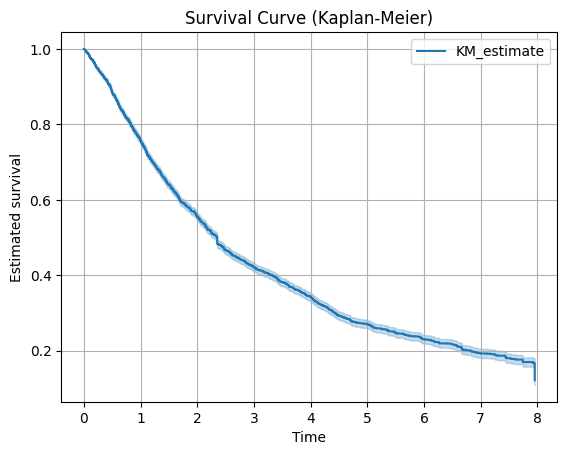

In [93]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Initialisation
kmf = KaplanMeierFitter()

# Ajustement du modèle
kmf.fit(durations=df_significant['time'], event_observed=df_significant['event'])

# Affichage de la courbe
kmf.plot_survival_function()
plt.title("Survival Curve (Kaplan-Meier)")
plt.xlabel("Time")
plt.ylabel("Estimated survival")
plt.grid()
plt.show()

In [98]:
df_significant = pl.from_pandas(df_significant)

In [101]:
df_significant = df_significant.with_columns(
    pl.when(pl.col("is_a_Female") == 1).then(0).otherwise(1).alias("is_a_Male")
)

In [102]:
df_significant

CHR,VAF,DEPTH,BM_BLAST,WBC,ANC,HB,PLT,is_a_Female,is_inversion_anomaly,is_down_syndrome,is_trisomy_8,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_complex_karyo,time,event,is_a_Male
f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,bool,i32
11.0,0.083,0.543657,0.162162,0.58871,0.601942,0.402778,0.852321,1,0,0,0,0,0,0,0,0,5.819178,false,0
5.0,0.022,0.217126,0.162162,0.58871,0.601942,0.402778,0.852321,1,0,0,0,0,0,0,0,0,5.819178,false,0
3.0,0.41,0.361877,0.162162,0.58871,0.601942,0.402778,0.852321,1,0,0,0,0,0,0,0,0,5.819178,false,0
4.0,0.43,0.340837,0.162162,0.58871,0.601942,0.402778,0.852321,1,0,0,0,0,0,0,0,0,5.819178,false,0
2.0,0.0898,0.389649,0.162162,0.58871,0.601942,0.402778,0.852321,1,0,0,0,0,0,0,0,0,5.819178,false,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3.0,0.192452,0.418351,0.945946,0.675,0.763754,0.65463,0.029536,0,0,0,0,0,0,0,0,0,0.671233,false,1
3.0,0.192452,0.418351,0.432432,0.241935,0.186408,0.54537,0.135021,0,0,0,0,0,1,0,0,0,3.69589,false,1
3.0,0.192452,0.418351,0.972973,1.0,0.621359,0.328704,0.322785,1,0,0,0,0,0,0,0,0,0.468493,true,0


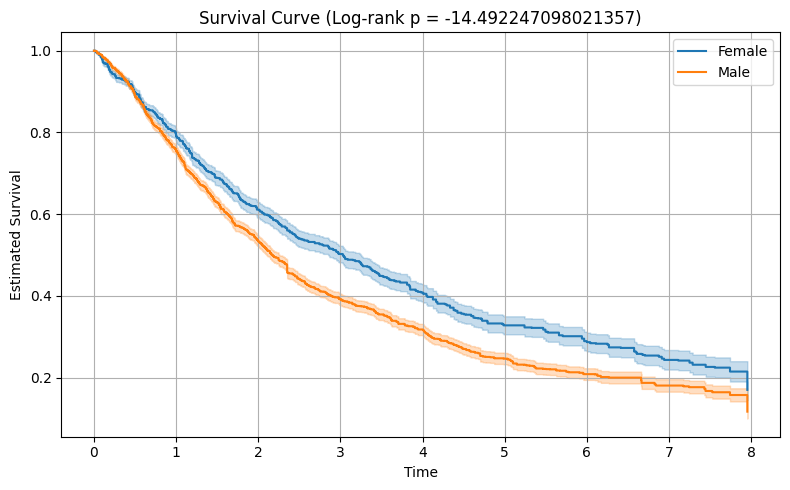

In [115]:
from lifelines.statistics import logrank_test

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

data_A = df_significant.filter(pl.col("is_a_Female") == 1)
data_B = df_significant.filter(pl.col("is_a_Female") == 0)

# Plot survival functions
plt.figure(figsize=(8, 5))
kmf_A.fit(data_A['time'], data_A['event'], label='Female')
kmf_A.plot_survival_function()

kmf_B.fit(data_B['time'], data_B['event'], label='Male')
kmf_B.plot_survival_function()

# Perform log-rank test
results = logrank_test(
    data_A['time'], data_B['time'],
    event_observed_A=data_A['event'],
    event_observed_B=data_B['event']
)

# Add p-value to the plot
plt.title(f"Survival Curve (Log-rank p = {np.log10(results.p_value)})")
plt.xlabel("Time")
plt.ylabel("Estimated Survival")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

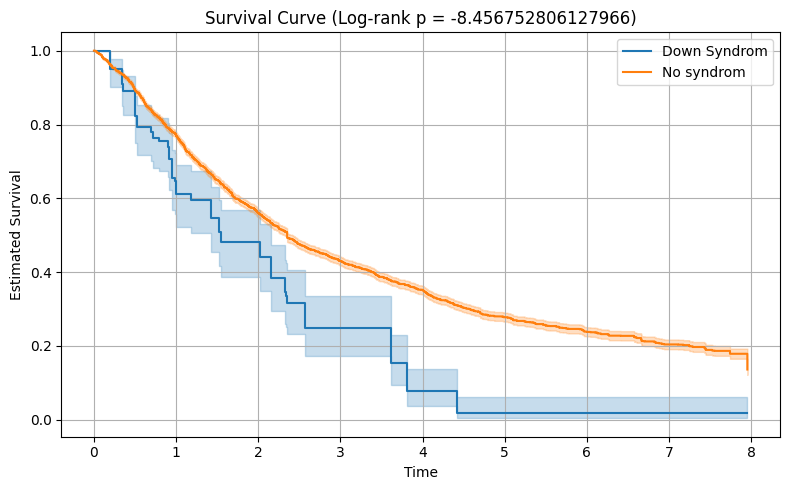

In [119]:
from lifelines.statistics import logrank_test

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

data_A = df_significant.filter(pl.col("is_down_syndrome") == 1)
data_B = df_significant.filter(pl.col("is_down_syndrome") == 0)

# Plot survival functions
plt.figure(figsize=(8, 5))
kmf_A.fit(data_A['time'], data_A['event'], label='Down Syndrom')
kmf_A.plot_survival_function()

kmf_B.fit(data_B['time'], data_B['event'], label='No syndrom')
kmf_B.plot_survival_function()

# Perform log-rank test
results = logrank_test(
    data_A['time'], data_B['time'],
    event_observed_A=data_A['event'],
    event_observed_B=data_B['event']
)

# Add p-value to the plot
plt.title(f"Survival Curve (Log-rank p = {np.log10(results.p_value)})")
plt.xlabel("Time")
plt.ylabel("Estimated Survival")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

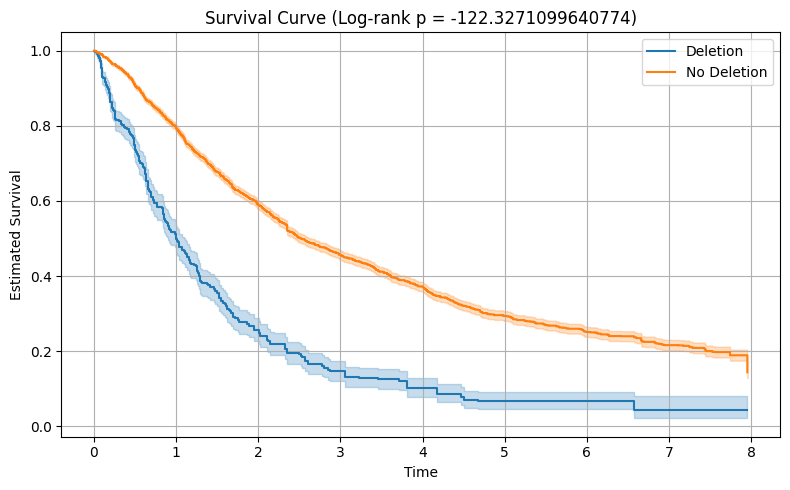

In [121]:
from lifelines.statistics import logrank_test

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

data_A = df_significant.filter(pl.col("is_deleted_chromsome") == 1)
data_B = df_significant.filter(pl.col("is_deleted_chromsome") == 0)

# Plot survival functions
plt.figure(figsize=(8, 5))
kmf_A.fit(data_A['time'], data_A['event'], label='Deletion')
kmf_A.plot_survival_function()

kmf_B.fit(data_B['time'], data_B['event'], label='No Deletion')
kmf_B.plot_survival_function()

# Perform log-rank test
results = logrank_test(
    data_A['time'], data_B['time'],
    event_observed_A=data_A['event'],
    event_observed_B=data_B['event']
)

# Add p-value to the plot
plt.title(f"Survival Curve (Log-rank p = {np.log10(results.p_value)})")
plt.xlabel("Time")
plt.ylabel("Estimated Survival")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

([], [])

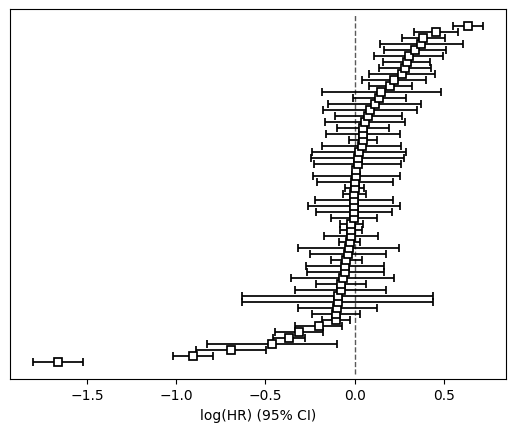

In [123]:
cph.plot()
plt.yticks([])